<a href="https://colab.research.google.com/github/cgm2179/Branch_2_Diffusion_Transformer_efficiency_for_small_model/blob/main/Section%207%20-%20Cameron's%20Version/regime%201%20-%20CelebA%20Autoencoder/CelebA%20Autoencoder%20-%2006_compare_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 7 — CNN regime 1 (CelebA Autoencoder (64px)) · Compare Results
Loads the 5 methods' `results/*.json` from Drive (missing ones skipped). MSE + PSNR + SSIM, cost/memory, three-factor cos-sweep head-to-head, an RGB sample-reconstruction grid, and a figures+CSV export.

## 1. Setup + Load Results

In [1]:
import os, json, math, torch
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
device='cuda' if torch.cuda.is_available() else 'cpu'
USE_DRIVE, DRIVE_SUBDIR = True, 'Section7_r1_celeba'
if USE_DRIVE:
    try:
        from google.colab import drive; drive.mount('/content/drive'); STORE=os.path.join('/content/drive/MyDrive',DRIVE_SUBDIR)
    except Exception as e:
        print('Drive mount failed:',e); STORE=os.path.join('/content',DRIVE_SUBDIR)
else:
    STORE=os.path.join('.',DRIVE_SUBDIR)
RESULTS_DIR=os.path.join(STORE,'results'); CKPT_DIR=os.path.join(STORE,'checkpoints')
EXTRA_RESULTS_DIRS = []   # merge results JSONs exported from other Google accounts (see merge cell)
EXTRA_CKPT_DIRS    = []
METHODS=['backprop','two_factor','three_factor_clean','three_factor_normal','three_factor_noisy','backprop_100M']
LABELS={'backprop':'Backprop','two_factor':'Two-factor Hebbian','three_factor_clean':'Three-factor clean (cos~0.5)','three_factor_normal':'Three-factor normal (cos~0.09)','three_factor_noisy':'Three-factor noisy (cos~0.01)','backprop_100M':'Backprop 100M (ceiling)'}
COLORS={'backprop':'#1F3864','two_factor':'#B8860B','three_factor_clean':'#C62828','three_factor_normal':'#E67E22','three_factor_noisy':'#7B1FA2','backprop_100M':'#2E7D32'}
def _find(m):
    for d in [RESULTS_DIR]+EXTRA_RESULTS_DIRS:
        p=os.path.join(d,f'{m}.json')
        if os.path.exists(p): return p
    return None
R={}
for m in METHODS:
    p=_find(m)
    if p:
        R[m]=json.load(open(p)); s=R[m]['summary']; md=R[m]['meta']
        print(f'loaded {m:24} {md["total_steps"]:>9,} steps  {md["wall_clock_sec"]/3600:5.2f}h  best MSE {s["best_mse"]:.5f}  best PSNR {s["best_psnr"]:.2f}dB  best SSIM {s["best_ssim"]:.3f}')
    else:
        print(f'MISSING {m}.json (run the {m} notebook first)')

Mounted at /content/drive
loaded backprop                 1,486,925 steps   2.00h  best MSE 0.00504  best PSNR 22.97dB  best SSIM 0.744
loaded two_factor               2,486,626 steps   2.00h  best MSE 0.09013  best PSNR 10.45dB  best SSIM 0.281
loaded three_factor_clean              10 steps   2.13h  best MSE 0.08845  best PSNR 10.53dB  best SSIM 0.281
loaded three_factor_normal            382 steps   2.00h  best MSE 0.07639  best PSNR 11.17dB  best SSIM 0.300
loaded three_factor_noisy          30,705 steps   2.00h  best MSE 0.01452  best PSNR 18.38dB  best SSIM 0.546
loaded backprop_100M              175,801 steps   2.00h  best MSE 0.00180  best PSNR 27.44dB  best SSIM 0.891


## (optional) merge results from another account

In [2]:
# --- OPTIONAL: merge results exported from ANOTHER Google account (upload <method>.json / .pt) ---
import os
try:
    from google.colab import files
    up = files.upload(); import shutil
    for fn in up:
        dst = '/content/extra_results' if fn.endswith('.json') else '/content/extra_ckpts'
        os.makedirs(dst, exist_ok=True); shutil.move(fn, os.path.join(dst, fn))
    if os.path.isdir('/content/extra_results') and '/content/extra_results' not in EXTRA_RESULTS_DIRS:
        EXTRA_RESULTS_DIRS.append('/content/extra_results')
    if os.path.isdir('/content/extra_ckpts') and '/content/extra_ckpts' not in EXTRA_CKPT_DIRS:
        EXTRA_CKPT_DIRS.append('/content/extra_ckpts')
    print('re-run the load cell above; EXTRA_RESULTS_DIRS =', EXTRA_RESULTS_DIRS)
except Exception as e:
    print('nothing uploaded (fine if all results are on this Drive):', e)

re-run the load cell above; EXTRA_RESULTS_DIRS = []


## 2. Compare curves (MSE + PSNR + SSIM)

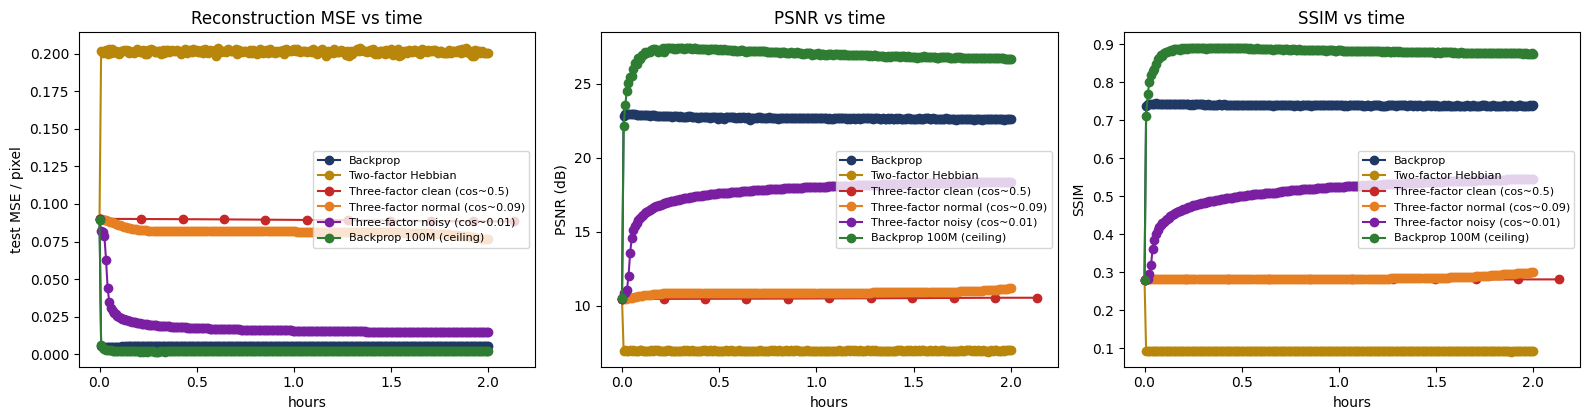

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
for m in R:
    c = R[m]['curve']; hrs = [t/3600 for t in c['t_sec']]
    ax[0].plot(hrs, c['test_mse'],  'o-', color=COLORS[m], label=LABELS[m])
    ax[1].plot(hrs, c['test_psnr'], 'o-', color=COLORS[m], label=LABELS[m])
    ax[2].plot(hrs, c['test_ssim'], 'o-', color=COLORS[m], label=LABELS[m])
ax[0].set_xlabel('hours'); ax[0].set_ylabel('test MSE / pixel'); ax[0].set_title('Reconstruction MSE vs time'); ax[0].legend(fontsize=8)
ax[1].set_xlabel('hours'); ax[1].set_ylabel('PSNR (dB)'); ax[1].set_title('PSNR vs time'); ax[1].legend(fontsize=8)
ax[2].set_xlabel('hours'); ax[2].set_ylabel('SSIM'); ax[2].set_title('SSIM vs time'); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Cost & Memory

In [4]:
def fwd_equiv(m):
    st = R[m]['meta']['total_steps']
    if m.startswith('three_factor'): return st * 2 * R[m]['meta']['config'].get('M', 0)
    if m.startswith('backprop'): return st * 3
    return st * 2
print(f'{"method":30}{"steps":>10}{"fwd-equiv":>14}{"wall h":>8}{"peak MB":>9}')
print('-'*71)
for m in R:
    md = R[m]['meta']
    print(f'{LABELS[m]:30}{md["total_steps"]:>10,}{fwd_equiv(m):>14,}{md["wall_clock_sec"]/3600:>8.2f}{md.get("peak_mem_mb", float("nan")):>9.1f}')

method                             steps     fwd-equiv  wall h  peak MB
-----------------------------------------------------------------------
Backprop                       1,486,925     4,460,775    2.00   2937.3
Two-factor Hebbian             2,486,626     4,973,252    2.00   2915.2
Three-factor clean (cos~0.5)          10     6,744,700    2.13  33701.3
Three-factor normal (cos~0.09)       382     6,312,168    2.00  12304.4
Three-factor noisy (cos~0.01)     30,705     6,202,410    2.00  12303.4
Backprop 100M (ceiling)          175,801       527,403    2.00   8101.0


## Peak training memory — backprop vs. forward-only (no activation tape)

Measures the **activation tape** backprop must retain for its backward pass — memory the forward-only three-factor rule never allocates (it only *evaluates* the loss). Self-contained and unexecuted: run it to print the numbers next to the accuracy results. Exact (`torch.autograd.graph.saved_tensors_hooks`), at this section's training batch size.

In [ ]:
# ============================================================================
# Peak training memory: backprop vs the forward-only three-factor rule.
# Backprop must retain an "activation tape" (one saved tensor per layer op) so
# the backward pass can run; the forward-only rule only EVALUATES the loss, so
# it stores none of it -> training memory stays at the inference footprint.
# Measured exactly via autograd's own saved-tensor hooks (not an estimate).
# Also writes peak_training_memory.csv into the exports/ folder so it rides
# along in the results zip next to summary.csv. Self-contained + unexecuted.
# ============================================================================
import torch, torch.nn as nn, torch.nn.functional as F
_MEM_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def _activation_tape_bytes(model, xshape, lossfn, make_target):
    model = model.to(_MEM_DEVICE)
    _pp = {p.untyped_storage().data_ptr() for p in model.parameters()}
    _seen, _isp = {}, {}
    def _pack(t):
        st = t.untyped_storage(); dp = st.data_ptr()
        _seen[dp] = st.nbytes(); _isp[dp] = (dp in _pp); return t
    def _unpack(t): return t
    x = torch.randn(*xshape, device=_MEM_DEVICE)
    with torch.autograd.graph.saved_tensors_hooks(_pack, _unpack):
        out = model(x); loss = lossfn(out, make_target(out)); loss.backward()
    return sum(nb for dp, nb in _seen.items() if not _isp[dp])  # activations only (params excluded)

def _report_training_memory(label, model, xshape, lossfn, make_target):
    P = sum(p.numel() for p in model.parameters()); pmem = P*4
    tape = _activation_tape_bytes(model, xshape, lossfn, make_target)
    common = 4*pmem; bp, loc = common + tape, common; MB = 1e6
    print("="*78)
    print(f"PEAK TRAINING MEMORY  |  {label}")
    print(f"  params P = {P:,}  ({pmem/MB:.2f} MB weights)   |   batch = {xshape[0]}   |   device = {_MEM_DEVICE}")
    print("-"*78)
    print(f"  activation tape backprop must retain : {tape/MB:8.2f} MB   ({tape/max(pmem,1):.1f}x the weights)")
    print(f"  forward-only three-factor rule       : {0.0:8.2f} MB   (no tape -- structural)")
    print(f"  est. training memory (same Adam both = 4P shared):")
    print(f"      backprop     : {bp/MB:8.2f} MB")
    print(f"      forward-only : {loc/MB:8.2f} MB   ->  backprop needs {bp/max(loc,1):.2f}x the memory")
    print(f"  (tape ~ linear in batch; measured via torch.autograd saved_tensors_hooks)")
    print("="*78)
    return {"section": label, "arch": type(model).__name__.replace("_Mem",""),
            "params": P, "batch": xshape[0], "weights_MB": round(pmem/MB, 2),
            "activation_tape_MB": round(tape/MB, 2), "tape_over_weights": round(tape/max(pmem,1), 2),
            "backprop_train_MB": round(bp/MB, 2), "forward_only_train_MB": round(loc/MB, 2),
            "backprop_over_forward_only": round(bp/max(loc,1), 2)}

class _MemConvAE(nn.Module):
    def __init__(self, conv_c=32, latent=116):
        super().__init__(); c2=2*conv_c; self._c2=c2
        self.enc=nn.Sequential(nn.Conv2d(3,conv_c,3,2,1),nn.ReLU(),nn.Conv2d(conv_c,conv_c,3,2,1),nn.ReLU(),nn.Conv2d(conv_c,c2,3,2,1),nn.ReLU())
        self.fc1=nn.Linear(c2*8*8, latent); self.fc2=nn.Linear(latent, c2*8*8)
        self.dec=nn.Sequential(nn.Upsample(scale_factor=2,mode='nearest'),nn.Conv2d(c2,conv_c,3,padding=1),nn.ReLU(),nn.Upsample(scale_factor=2,mode='nearest'),nn.Conv2d(conv_c,conv_c,3,padding=1),nn.ReLU(),nn.Upsample(scale_factor=2,mode='nearest'),nn.Conv2d(conv_c,3,3,padding=1))
    def forward(self,x):
        h=self.enc(x); b=h.shape[0]; z=self.fc1(h.reshape(b,-1))
        h2=self.fc2(z).reshape(b,self._c2,8,8); return self.dec(h2)
_MEM_ROW = _report_training_memory("S7 CNN autoencoder (CelebA 64x64)", _MemConvAE(), (128,3,64,64), lambda o,t: F.mse_loss(o,t), lambda o: torch.rand_like(o))

# --- stash + persist so the export cell's zip picks it up (rides next to summary.csv) ---
PEAK_MEM_ROWS = [_MEM_ROW]
try:
    import os as _os, csv as _csv
    if 'STORE' in globals():
        _ed = _os.path.join(STORE, 'exports'); _os.makedirs(_ed, exist_ok=True)
        with open(_os.path.join(_ed, 'peak_training_memory.csv'), 'w', newline='') as _f:
            _w = _csv.DictWriter(_f, fieldnames=list(PEAK_MEM_ROWS[0].keys())); _w.writeheader()
            for _r in PEAK_MEM_ROWS: _w.writerow(_r)
        print('  saved ->', _os.path.join(_ed, 'peak_training_memory.csv'))
    else:
        print('  (STORE not defined yet -- CSV will be written by the export cell / re-run after Setup)')
except Exception as _e:
    print('  (peak_training_memory.csv not written:', _e, ')')


## 4. Head-to-head — three-factor cos sweep

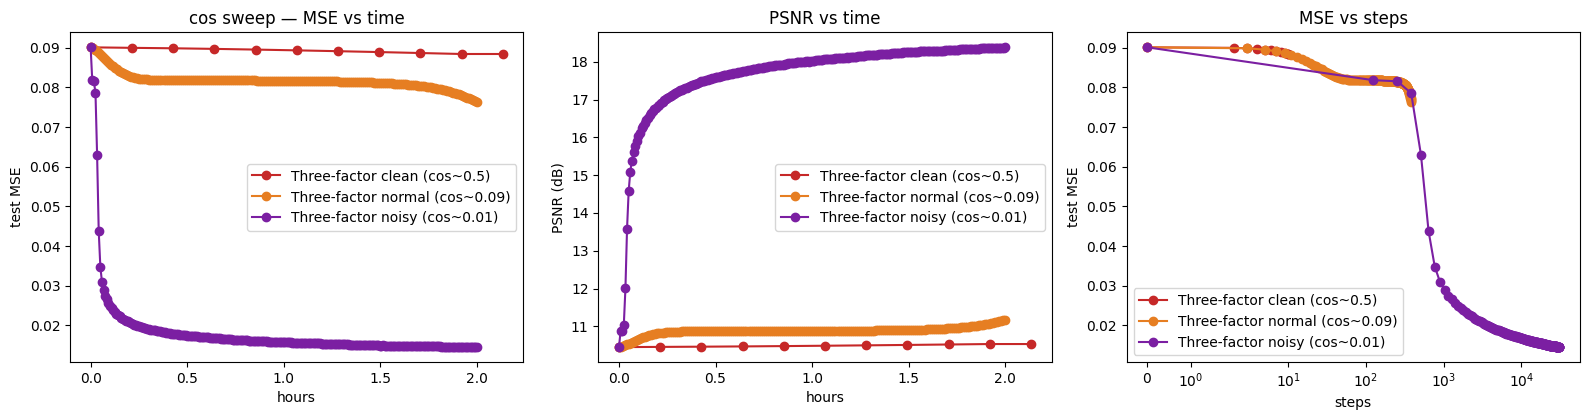

variant                                M    cos~     steps   best_mse  best_psnr  best_ssim
-------------------------------------------------------------------------------------------
Three-factor clean (cos~0.5)     337,235   0.500        10    0.08845      10.53      0.281
Three-factor normal (cos~0.09)     8,262   0.090       382    0.07639      11.17      0.300
Three-factor noisy (cos~0.01)        101   0.010    30,705    0.01452      18.38      0.546

Lowest best MSE in the budget: Three-factor noisy (cos~0.01).


In [5]:
tf = [m for m in ['three_factor_clean','three_factor_normal','three_factor_noisy'] if m in R]
if len(tf) >= 2:
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
    for m in tf:
        c = R[m]['curve']; hrs=[t/3600 for t in c['t_sec']]
        ax[0].plot(hrs, c['test_mse'],  'o-', color=COLORS[m], label=LABELS[m])
        ax[1].plot(hrs, c['test_psnr'], 'o-', color=COLORS[m], label=LABELS[m])
        ax[2].plot(c['step'], c['test_mse'], 'o-', color=COLORS[m], label=LABELS[m])
    ax[0].set_xlabel('hours'); ax[0].set_ylabel('test MSE'); ax[0].set_title('cos sweep — MSE vs time'); ax[0].legend()
    ax[1].set_xlabel('hours'); ax[1].set_ylabel('PSNR (dB)'); ax[1].set_title('PSNR vs time'); ax[1].legend()
    ax[2].set_xscale('symlog'); ax[2].set_xlabel('steps'); ax[2].set_ylabel('test MSE'); ax[2].set_title('MSE vs steps'); ax[2].legend()
    plt.tight_layout(); plt.show()
    print(f'{"variant":30}{"M":>10}{"cos~":>8}{"steps":>10}{"best_mse":>11}{"best_psnr":>11}{"best_ssim":>11}')
    print('-'*91)
    for m in tf:
        md, s = R[m]['meta'], R[m]['summary']; M = md['config'].get('M') or 0; P = md['P']
        cos = (M/(M+P+1))**0.5 if M else float('nan')
        print(f'{LABELS[m]:30}{M:>10,}{cos:>8.3f}{md["total_steps"]:>10,}{s["best_mse"]:>11.5f}{s["best_psnr"]:>11.2f}{s["best_ssim"]:>11.3f}')
    best = min(tf, key=lambda m: R[m]['summary']['best_mse'])
    print(f'\nLowest best MSE in the budget: {LABELS[best]}.')
else:
    print('Head-to-head needs >=2 three-factor variants (03/04/05).')

## CelebA data setup (for the grid below — Colab)

In [6]:
# --- CelebA data (run this FIRST on Colab) --------------------------------------------------------
# The Data cell below reads CELEBA_ROOT. Point it at a folder that (recursively) holds the aligned
# JPGs (and list_attr_celeba.csv for the attribute classifier). First run decodes a subset + caches a .pt.
import os, glob, shutil
CELEBA_ROOT = globals().get('CELEBA_ROOT', '/content/celeba')     # <- edit if your images live elsewhere
if not glob.glob(os.path.join(CELEBA_ROOT, '**', '*.jpg'), recursive=True):
    # Option A -- Kaggle API (fast): upload kaggle.json (left panel > Files > upload), then this pulls it:
    try:
        os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
        if os.path.exists('kaggle.json'):
            shutil.copy('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
            os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
        os.system('pip -q install kaggle')
        os.system('kaggle datasets download -d jessicali9530/celeba-dataset -p "%s" --unzip -q' % CELEBA_ROOT)
    except Exception as e:
        print('Kaggle download failed:', e)
    # Option B -- from Google Drive (put celeba.zip on your Drive); uncomment to use instead of A:
    # from google.colab import drive; drive.mount('/content/drive')
    # os.makedirs(CELEBA_ROOT, exist_ok=True); os.system('unzip -q "/content/drive/MyDrive/celeba.zip" -d "%s"' % CELEBA_ROOT)
_n = len(glob.glob(os.path.join(CELEBA_ROOT, '**', '*.jpg'), recursive=True))
_attr = bool(glob.glob(os.path.join(CELEBA_ROOT, '**', 'list_attr_celeba.csv'), recursive=True))
assert _n, ('no CelebA jpgs under %r -- upload kaggle.json (Option A) or a Drive zip (Option B) and '
            're-run, or set CELEBA_ROOT to an existing folder.' % CELEBA_ROOT)
print('CELEBA_ROOT =', CELEBA_ROOT, '|', format(_n, ','), 'jpgs | attr csv present:', _attr)

CELEBA_ROOT = /content/celeba | 202,599 jpgs | attr csv present: True


## 5. Sample reconstructions (best model)

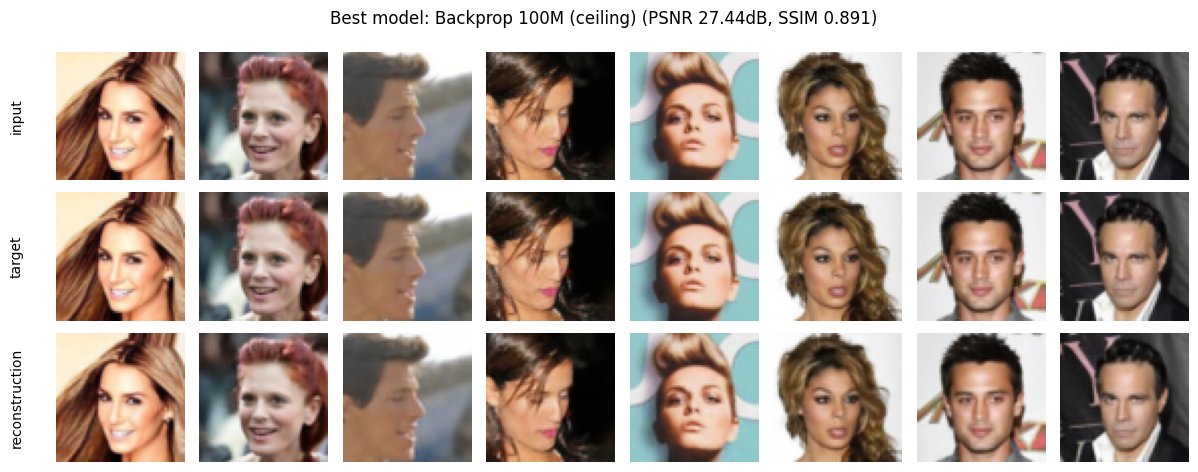

In [7]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvAE(nn.Module):
    """Conv encoder -> dense latent bottleneck -> Upsample+Conv decoder -> 3x64x64 logits.
    Three stride-2 downs (64->8) keep the 8x8 bottleneck so P stays ~1.01M at 64px.
    No BatchNorm (vmap-clean); Upsample+Conv instead of ConvTranspose (vmap-safe)."""
    def __init__(self, conv_c=32, latent=116):
        super().__init__()
        c2 = 2 * conv_c
        self.enc = nn.Sequential(
            nn.Conv2d(3, conv_c, 3, stride=2, padding=1), nn.ReLU(),      # 64 -> 32
            nn.Conv2d(conv_c, conv_c, 3, stride=2, padding=1), nn.ReLU(), # 32 -> 16
            nn.Conv2d(conv_c, c2, 3, stride=2, padding=1), nn.ReLU(),     # 16 -> 8
        )
        self._c2 = c2
        self.fc1 = nn.Linear(c2 * 8 * 8, latent)
        self.fc2 = nn.Linear(latent, c2 * 8 * 8)
        self.dec = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),                 # 8 -> 16
            nn.Conv2d(c2, conv_c, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),                 # 16 -> 32
            nn.Conv2d(conv_c, conv_c, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),                 # 32 -> 64
            nn.Conv2d(conv_c, 3, 3, padding=1),
        )
    def forward(self, x):
        h = self.enc(x)
        b = h.shape[0]
        z = self.fc1(h.reshape(b, -1))
        h2 = self.fc2(z).reshape(b, self._c2, 8, 8)
        return self.dec(h2)                                              # (B,3,64,64) logits

# sample reconstructions for the best model (highest PSNR): input | target | reconstruction (RGB)
import torch, torchvision
def _ckpt(m):
    for d in [CKPT_DIR] + EXTRA_CKPT_DIRS:
        p = os.path.join(d, f'{m}.pt')
        if os.path.exists(p): return p
    return None
_avail = [m for m in R if _ckpt(m)]
if _avail:
    best = max(_avail, key=lambda m: R[m]['summary']['best_psnr'])
    cfg = R[best]['meta']['config']
    net = ConvAE(cfg['CONV_C'], cfg['LATENT']).to(device)
    ck = torch.load(_ckpt(best), map_location=device)['method']
    net.load_state_dict(ck['net'] if 'net' in ck else ck['params']); net.eval()
    import glob, numpy as np
    from PIL import Image
    _CR = globals().get('CELEBA_ROOT', './celeba'); _RES = 64
    _fs = sorted(glob.glob(os.path.join(_CR, '**', '*.jpg'), recursive=True))[:8]
    def _dec(p):
        im = Image.open(p).convert('RGB'); w, h = im.size; s = min(w, h)
        im = im.crop(((w-s)//2, (h-s)//2, (w+s)//2, (h+s)//2)).resize((_RES, _RES), Image.BILINEAR)
        return torch.from_numpy(np.asarray(im, dtype=np.float32)/255.0).permute(2, 0, 1)
    x = torch.stack([_dec(p) for p in _fs]).to(device)
    torch.manual_seed(cfg['SEED']); xin = x + cfg['CORRUPT_SIGMA']*torch.randn_like(x) if cfg['CORRUPT_SIGMA']>0 else x
    with torch.no_grad(): rec = torch.sigmoid(net(xin)).clamp(0,1)
    def _show(ax, img): ax.imshow(img.permute(1,2,0).cpu().clamp(0,1).numpy()); ax.axis('off')
    fig, ax = plt.subplots(3, 8, figsize=(12, 4.8))
    for j in range(8):
        _show(ax[0,j], xin[j].clamp(0,1)); _show(ax[1,j], x[j]); _show(ax[2,j], rec[j])
    ax[0,0].text(-0.3,0.5,'input',rotation=90,va='center',ha='center',transform=ax[0,0].transAxes)
    ax[1,0].text(-0.3,0.5,'target',rotation=90,va='center',ha='center',transform=ax[1,0].transAxes)
    ax[2,0].text(-0.3,0.5,'reconstruction',rotation=90,va='center',ha='center',transform=ax[2,0].transAxes)
    plt.suptitle(f'Best model: {LABELS[best]} (PSNR {R[best]["summary"]["best_psnr"]:.2f}dB, SSIM {R[best]["summary"]["best_ssim"]:.3f})')
    plt.tight_layout(); plt.show()
else:
    print('no checkpoints available (run the method notebooks first)')

## 6. Summary table

In [8]:
print(f'{"Experiment":30}{"Steps":>10}{"Init MSE":>11}{"Best MSE":>11}{"Best PSNR":>11}{"Best SSIM":>11}')
print('-'*84)
for m in R:
    md, s = R[m]['meta'], R[m]['summary']
    print(f'{LABELS[m]:30}{md["total_steps"]:>10,}{s["initial_mse"]:>11.5f}{s["best_mse"]:>11.5f}{s["best_psnr"]:>11.2f}{s["best_ssim"]:>11.3f}')

Experiment                         Steps   Init MSE   Best MSE  Best PSNR  Best SSIM
------------------------------------------------------------------------------------
Backprop                       1,486,925    0.09013    0.00504      22.97      0.744
Two-factor Hebbian             2,486,626    0.09013    0.09013      10.45      0.281
Three-factor clean (cos~0.5)          10    0.09013    0.08845      10.53      0.281
Three-factor normal (cos~0.09)       382    0.09013    0.07639      11.17      0.300
Three-factor noisy (cos~0.01)     30,705    0.09013    0.01452      18.38      0.546
Backprop 100M (ceiling)          175,801    0.08932    0.00180      27.44      0.891


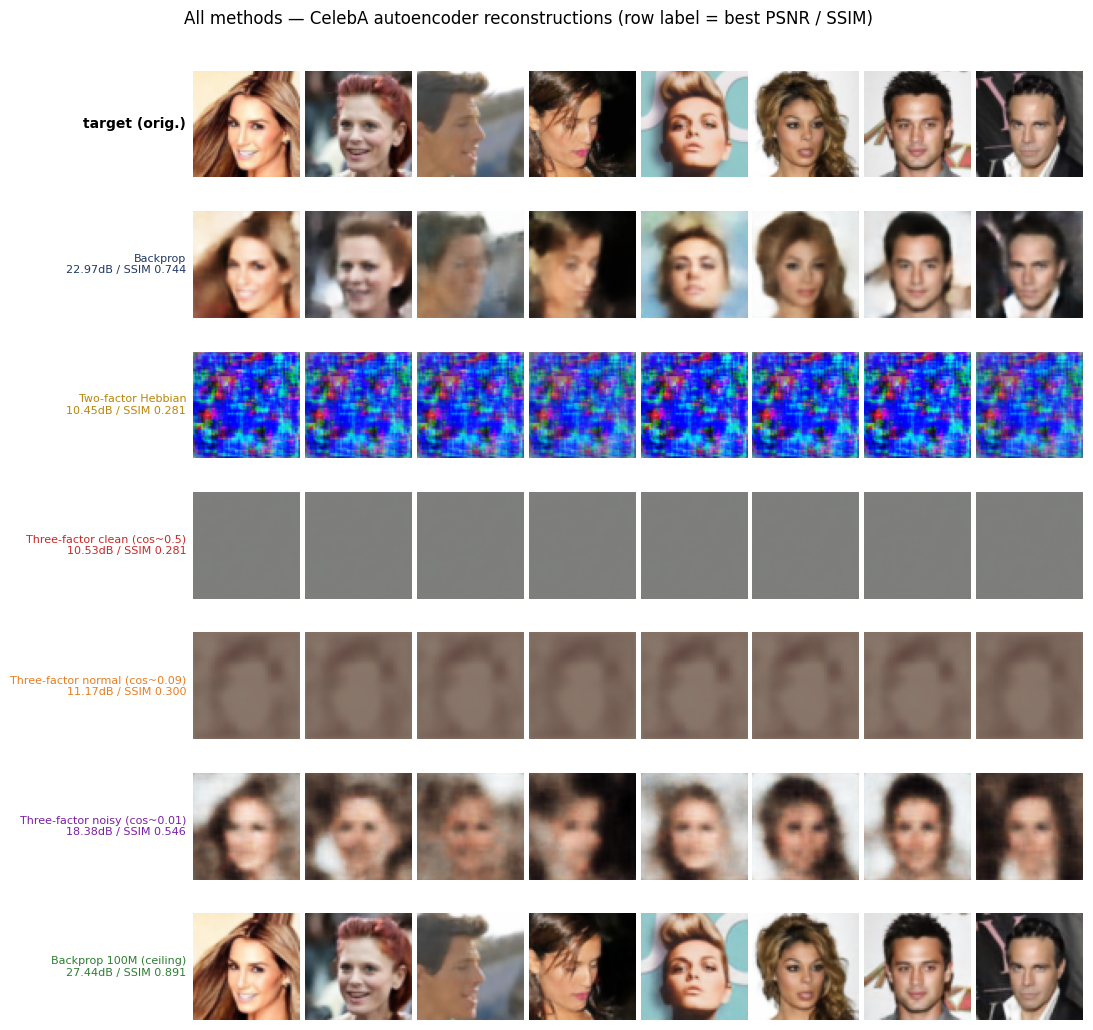

In [10]:
# --- ALL methods — sample reconstructions side-by-side (target on top, one row per method) ---
# Loads every available checkpoint, reconstructs the SAME faces, and stacks them so you can read a
# column top-to-bottom to compare methods. Run the cells above first (defines ConvAE, R, CKPT_DIR).
import os, glob, numpy as np, torch
from PIL import Image

N_SHOW = 8
_CR  = globals().get('CELEBA_ROOT', './celeba'); _RES = 64
_fs  = sorted(glob.glob(os.path.join(_CR, '**', '*.jpg'), recursive=True))[:N_SHOW]
assert _fs, f'no CelebA jpgs under {_CR!r} — run the CelebA data-setup cell first'
def _dec(p):
    im = Image.open(p).convert('RGB'); w, h = im.size; s = min(w, h)
    im = im.crop(((w-s)//2,(h-s)//2,(w+s)//2,(h+s)//2)).resize((_RES,_RES), Image.BILINEAR)
    return torch.from_numpy(np.asarray(im, np.float32)/255.).permute(2,0,1)
x = torch.stack([_dec(p) for p in _fs]).to(device)                       # (N,3,64,64) clean targets

def _ckpt(m):
    for d in [CKPT_DIR] + EXTRA_CKPT_DIRS:
        p = os.path.join(d, f'{m}.pt')
        if os.path.exists(p): return p
    return None

rows = []   # (label, color, images) — one per method that has a checkpoint, in canonical order
for m in METHODS:
    if m not in R or _ckpt(m) is None: continue
    cfg = R[m]['meta']['config']
    net = ConvAE(cfg['CONV_C'], cfg['LATENT']).to(device)
    ck  = torch.load(_ckpt(m), map_location=device)['method']
    net.load_state_dict(ck['net'] if 'net' in ck else ck['params']); net.eval()
    torch.manual_seed(cfg['SEED'])                                       # per-method input (=x when CORRUPT_SIGMA=0)
    xin = x + cfg['CORRUPT_SIGMA']*torch.randn_like(x) if cfg.get('CORRUPT_SIGMA',0)>0 else x
    with torch.no_grad(): rec = torch.sigmoid(net(xin)).clamp(0,1)
    s = R[m]['summary']
    rows.append((f'{LABELS[m]}\n{s["best_psnr"]:.2f}dB / SSIM {s["best_ssim"]:.3f}', COLORS[m], rec.cpu()))

if rows:
    n = len(_fs); R_ = len(rows) + 1
    def _show(ax, img): ax.imshow(img.permute(1,2,0).clamp(0,1).numpy()); ax.axis('off')
    fig, ax = plt.subplots(R_, n, figsize=(1.4*n, 1.5*R_), squeeze=False)
    for j in range(n): _show(ax[0,j], x[j].cpu())
    ax[0,0].text(-0.06,0.5,'target (orig.)', ha='right', va='center', transform=ax[0,0].transAxes, fontweight='bold')
    for i,(lab,col,imgs) in enumerate(rows, start=1):
        for j in range(n): _show(ax[i,j], imgs[j])
        ax[i,0].text(-0.06,0.5, lab, ha='right', va='center', transform=ax[i,0].transAxes, color=col, fontsize=8)
    plt.suptitle('All methods — CelebA autoencoder reconstructions (row label = best PSNR / SSIM)', y=0.985)
    plt.subplots_adjust(left=0.20, right=0.995, top=0.94, bottom=0.01, wspace=0.05, hspace=0.05)
    plt.show()
else:
    print('no checkpoints available — run the method notebooks (01–05/07) first')

## 7. Export figures + CSV → Drive

In [11]:
# Export every figure (PNG) + data (CSV) -> a Drive folder, then download a zip.
import os, csv, glob, shutil
EXPORT_DIR = os.path.join(STORE, 'exports'); os.makedirs(EXPORT_DIR, exist_ok=True)
if R:
    ckeys = []
    for m in R:
        for k in R[m]['curve']:
            if k not in ckeys: ckeys.append(k)
    with open(os.path.join(EXPORT_DIR, 'curves.csv'), 'w', newline='') as f:
        w = csv.writer(f); w.writerow(['method'] + ckeys)
        for m in R:
            c = R[m]['curve']; n = len(c.get('t_sec', []))
            for i in range(n): w.writerow([m] + [c[k][i] if (k in c and i < len(c[k])) else '' for k in ckeys])
    skeys = []
    for m in R:
        for k in R[m]['summary']:
            if k not in skeys: skeys.append(k)
    with open(os.path.join(EXPORT_DIR, 'summary.csv'), 'w', newline='') as f:
        w = csv.writer(f); w.writerow(['method','P','total_steps','wall_clock_h','M','cos'] + skeys)
        for m in R:
            md, s = R[m]['meta'], R[m]['summary']; M = md['config'].get('M') or 0
            cos = round((M/(M+md['P']+1))**0.5, 4) if M else ''
            w.writerow([m, md['P'], md['total_steps'], round(md['wall_clock_sec']/3600,3), M, cos] + [s.get(k,'') for k in skeys])
    print('wrote curves.csv, summary.csv')
def _save(fig, name): fig.savefig(os.path.join(EXPORT_DIR, name), dpi=130, bbox_inches='tight'); plt.close(fig)
if R:
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
    for m in R:
        c = R[m]['curve']; hrs=[t/3600 for t in c['t_sec']]
        ax[0].plot(hrs, c['test_mse'],'o-',color=COLORS[m],label=LABELS[m])
        ax[1].plot(hrs, c['test_psnr'],'o-',color=COLORS[m],label=LABELS[m])
        ax[2].plot(hrs, c['test_ssim'],'o-',color=COLORS[m],label=LABELS[m])
    ax[0].set_ylabel('test MSE'); ax[1].set_ylabel('PSNR (dB)'); ax[2].set_ylabel('SSIM')
    for a in ax: a.set_xlabel('hours'); a.legend(fontsize=8)
    _save(fig, 'curves_mse_psnr_ssim.png'); print('wrote comparison figure')
for d in {RESULTS_DIR, CKPT_DIR, STORE}:
    for png in glob.glob(os.path.join(d, '*.png')):
        try: shutil.copy(png, EXPORT_DIR)
        except Exception: pass
print('\nexport folder:', EXPORT_DIR); print(' ', sorted(os.listdir(EXPORT_DIR)))
_zt = '/content' if os.path.isdir('/content') else os.path.dirname(EXPORT_DIR)
zip_path = shutil.make_archive(os.path.join(_zt, DRIVE_SUBDIR + '_exports'), 'zip', EXPORT_DIR)
try:
    if os.path.abspath(os.path.dirname(zip_path)) != os.path.abspath(STORE): shutil.copy(zip_path, STORE)
except Exception as e: print('(could not copy zip to Drive):', e)
print('zip:', zip_path)
try:
    from google.colab import files; files.download(zip_path)
except Exception as e:
    print('(download only runs in Colab):', e)

wrote curves.csv, summary.csv
wrote comparison figure

export folder: /content/drive/MyDrive/Section7_r1_celeba/exports
  ['curves.csv', 'curves_mse_psnr_ssim.png', 'summary.csv']
zip: /content/Section7_r1_celeba_exports.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>